In [1]:
import glob
import numpy as np
from PIL import Image

#### 유사 이미지

In [2]:
dirNames = ['Aiden', 'Andrew', 'Cathy']

In [3]:
for name in dirNames:
    count = 0
    for file in sorted(glob.glob(f'data/Face/{name}/*.jpg')):
        img = Image.open(file)
        for a in range(-15, 15, 1):
           count+=1
           # 회전
           img2 = img.rotate(a)
           img2.save(f'data/FaceColor/{name}/rotation_{count:04d}.jpg')
           # 플립(반전)
           img3 = img2.transpose(Image.FLIP_LEFT_RIGHT)
           img3.save(f'data/FaceColor/{name}/flip_{count:04d}.jpg')

In [4]:
# 이름별 전체 file 갯수
18 * 30 * 2

1080

#### 전체 사진 중 최대 해상도 찾기
: Feature(해상도)의 수를 동일하게 하기 위함
- 해상도는 모두 짝수 (홀수면 사람이 수정했다는 의미)

In [5]:
widthRatio = []
heightRatio = []

for name in dirNames:
    count = 0
    for file in sorted(glob.glob(f'data/FaceColor/{name}/*jpg')):
        img = np.array(Image.open(file), dtype=np.int32)
        widthRatio.append(img.shape[1])
        heightRatio.append(img.shape[0])
        count+=1
    print(f'{name}:{count}')

Aiden:1080
Andrew:1080
Cathy:1080


In [6]:
# 최대해상도
print('높이 최대 해상도: ', np.max(heightRatio))
print('너비 최대 해상도: ', np.max(widthRatio))

높이 최대 해상도:  381
너비 최대 해상도:  299


해상도의 크기를 400 * 300으로 고정

#### 전체 사진을 400*300의 고정크기로 맞추기

In [7]:
for name in dirNames:
    fileCount = 0
    for file in sorted(glob.glob(f'data/FaceColor/{name}/*.jpg')):
        img = Image.open(file)
        # img = img.convert('L')
        imgArray = np.array(img)
        
        # ⭕ 수정 1: 1차원이 아니라 (행, 열) 형태의 2차원 배열로 선언해야 합니다.
        imgDummy = np.zeros((400, 300, 3))
        
        rowNme = (400 - imgArray.shape[0]) / 2
        colNme = (300 - imgArray.shape[1]) / 2
        
        k = 0
        for i in range(int(rowNme), int(rowNme) + imgArray.shape[0]):
            l = 0
            # ⭕ 수정 2: j의 시작 범위는 rowNme가 아니라 colNme가 되어야 합니다.
            for j in range(int(colNme), int(colNme) + imgArray.shape[1]):
                imgDummy[i, j] = imgArray[k, l]
                l += 1
            k += 1
            
        img2 = Image.fromarray(imgDummy.astype('uint8'))
        img2.save(f'data/FaceResult2/{name}/img_{fileCount:04}.jpg', 'JPEG') # 'JPG' 대신 'JPEG'가 안정적입니다.
        fileCount += 1

#### 사진들을 numpy 배열로 Train Data 만들기

In [9]:
number_of_data = 1080 * len(dirNames)
img_width_size = 300
img_height_size = 400
img_color = 3

In [10]:
train = np.zeros(
    number_of_data * img_width_size * img_height_size * img_color, dtype=np.int32
).reshape(number_of_data, img_height_size, img_width_size, img_color)

i = 0
for name in dirNames:
    for file in sorted(glob.glob(f'data/FaceResult2/{name}/*.jpg')):
        img= np.array(Image.open(file), dtype=np.int32)
        train[i, :, :] = img
        i += 1

In [11]:
train.shape

(3240, 400, 300, 3)

#### 이미지 확인

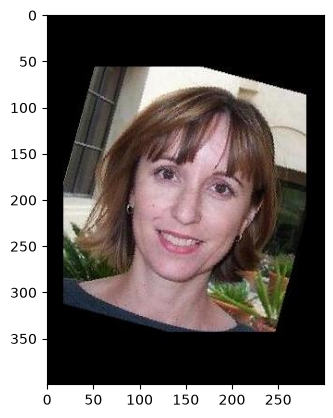

In [13]:
import matplotlib.pyplot as plt
plt.imshow(train[3000].reshape(400, 300,3), cmap='gray')
plt.show()

In [14]:
plt.figure(figsize=(20, 20))
orderNo = list(range(0, 1080*len(dirNames), 1080))
orderNo

[0, 1080, 2160]

<Figure size 2000x2000 with 0 Axes>

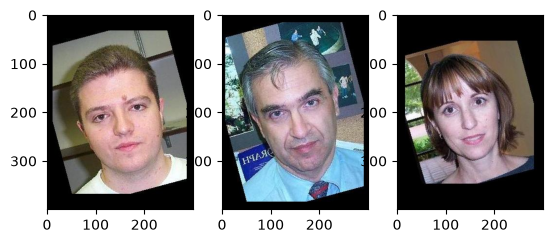

In [15]:
for i in range(1, len(dirNames)+1):
    plt.subplot(1, len(dirNames), i)
    plt.imshow(train[orderNo[i-1]].reshape(400, 300, 3), cmap='gray')
plt.show()

In [16]:
target = np.concatenate( # 합치기
    [np.zeros(1080), np.ones(1080), np.full(1080, 2)]
)

target

array([0., 0., 0., ..., 2., 2., 2.], shape=(3240,))

#### 채널 차원 추가와 정규화
- 랜덤포레스트같이 숫자의 크기를 비교하는 알고리즘은 정규화를 진행하지 않음
- train만 정규화, test는 진행 안함

In [17]:
train.shape

(3240, 400, 300, 3)

In [18]:
train = train.reshape(-1, 400, 300, 3) / 255.0

#### Train과 Test 분리

In [19]:
from sklearn.model_selection import train_test_split

train_data, test_data, train_target, test_target = \
    train_test_split(
        train,
        target,
        test_size=0.2,
        random_state=42
    )

In [20]:
print(train_data.shape, test_data.shape)
print(train_target.shape, test_target.shape)

(2592, 400, 300, 3) (648, 400, 300, 3)
(2592,) (648,)


#### CNN 만들기

In [21]:
from tensorflow import keras
from tensorflow.keras.layers import Input

In [22]:
model = keras.Sequential()

# 입력층
model.add(
    Input(shape=(400, 300, 3))
)

# ----- 합성곱층 만들기 -----

# 1번째 합성곱층
model.add(
    keras.layers.Conv2D(
        32, 
        kernel_size=3,
        activation='relu',
        padding='same'
    )
)
model.add(
    keras.layers.MaxPool2D(2) # max값만 추출해 사용
)

# 2번째 합성곱층
model.add(
    keras.layers.Conv2D(
        64, 
        kernel_size=3,
        activation='relu',
        padding='same'
    )
)
model.add(
    keras.layers.MaxPool2D(2) # max값만 추출해 사용
)

In [23]:
# ----- 심층 신경망 만들기 -----

# 심층 신경망의 입력층
model.add(
    keras.layers.Flatten()
)

# 심층 신경망의 은닉층
model.add(
    keras.layers.Dense(
        100,
        activation='relu'
    )
)

# Drop out 층: 과대적합 방지
model.add(
    keras.layers.Dropout(0.2) # 20% Train 데이터는 제외하고 학습
)

# 출력층
model.add(
    keras.layers.Dense(
        len(dirNames),
        activation='softmax'
    )
)

In [24]:
# 각 층의 순서 확인
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 400, 300, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 200, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 200, 150, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 100, 75, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 480000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │    48,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,019,795 (183.18 MB)

 Trainable params: 48,019,795 (183.18 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# 손실함수와 학습률 정의
model.compile(
    optimizer = 'adam', # 모델의 가중치(Weight)를 업데이트하는 알고리즘
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# 최적의 함수 저장
checkpoint_cb = keras.callbacks.ModelCheckpoint('data/best_cnn_face_color_model.keras')

# Epoch 실행 횟수 저장
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True
) 

In [26]:
history = model.fit(
    train_data,
    train_target,
    epochs = 10,
    validation_data = (test_data, test_target),
    callbacks = [checkpoint_cb, early_stopping_cb]
)

Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.9448 - loss: 0.6215 - val_accuracy: 1.0000 - val_loss: 2.3480e-04
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 72s 881ms/step - accuracy: 1.0000 - loss: 3.1547e-05 - val_accuracy: 1.0000 - val_loss: 7.1583e-04
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 71s 876ms/step - accuracy: 1.0000 - loss: 9.0506e-06 - val_accuracy: 1.0000 - val_loss: 4.4923e-04
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 70s 857ms/step - accuracy: 1.0000 - loss: 1.0328e-05 - val_accuracy: 1.0000 - val_loss: 2.8455e-04
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 68s 838ms/step - accuracy: 1.0000 - loss: 9.5659e-06 - val_accuracy: 1.0000 - val_loss: 4.5770e-04
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 69s 847ms/step - accuracy: 1.0000 - loss: 3.9991e-06 - val_accuracy: 1.0000 - val_loss: 4.9153e-04


In [27]:
model.evaluate(train_data, train_target)

81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 201ms/step - accuracy: 1.0000 - loss: 1.4746e-05


[1.4745617590961047e-05, 1.0]

In [28]:
model.evaluate(test_data, test_target)

21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 190ms/step - accuracy: 1.0000 - loss: 2.3480e-04


[0.0002347963600186631, 1.0]

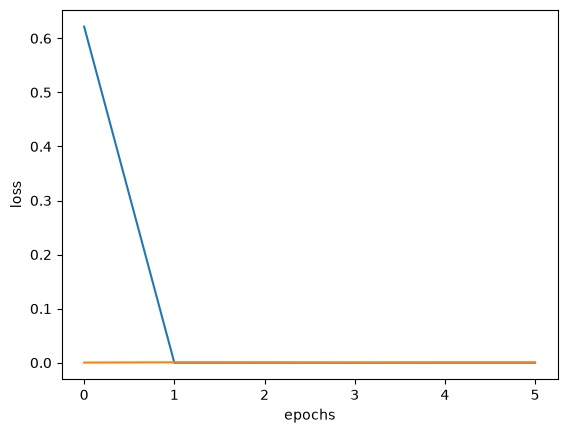

In [29]:
# 시각화
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

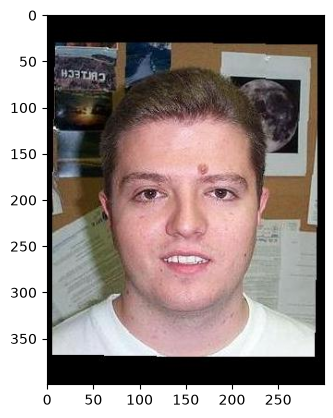

In [34]:
plt.imshow(test_data[100].reshape(400, 300, 3))
plt.show()

In [35]:
model.predict(test_data[100:101])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


array([[9.9999619e-01, 3.7617140e-06, 5.4119875e-10]], dtype=float32)

In [36]:
dirNames[np.argmax(model.predict(test_data[100:101]))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


'Aiden'